# Supp Fig 7 — Calibration analysis of the full model across evaluation strategies

In [1]:
# import modules
import os
import pandas as pd
import numpy as np
import pickle

# import scikit-learn modules
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier

# import visualization modules
import matplotlib.pyplot as plt

In [2]:
cwd = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(cwd, "..", ".."))

# build paths inside the repo
get_data_path = lambda folders, fname: os.path.normpath(
    os.path.join(BASE_DIR, *folders, fname)
)

# read training data which is used to train the model
file_path_training_data = get_data_path(['data', 'output', 'models'], 'training_data.csv')

In [3]:
# Strategy I
splits_path_I              = get_data_path(['data', 'output', 'models', 'model_I'],  'repeated_splits_I.pkl')
prediction_output_model_I  = get_data_path(['data', 'output', 'models', 'model_I'],  'RF_repeated_CV_predictions_for_calibration.csv')
summary_output_model_I     = get_data_path(['data', 'output', 'models', 'model_I'],  'RF_calibration_summary_by_repeat.csv')
calibration_plot_model_I   = get_data_path(['figures', 'model_on_GEMINI'],  'model_I_calibration_curve.png')
calibration_plot_model_I_n50 = get_data_path(['figures', 'model_on_GEMINI'],  'model_I_calibration_curve_n50.png')

# Strategy II
splits_path_II              = get_data_path(['data', 'output', 'models', 'model_II'],  'repeated_splits_II.pkl')
prediction_output_model_II  = get_data_path(['data', 'output', 'models', 'model_II'],  'RF_repeated_CV_predictions_for_calibration.csv')
summary_output_model_II     = get_data_path(['data', 'output', 'models', 'model_II'],  'RF_calibration_summary_by_repeat.csv')
calibration_plot_model_II   = get_data_path(['figures', 'model_on_GEMINI'],  'model_II_calibration_curve.png')
calibration_plot_model_II_n50 = get_data_path(['figures', 'model_on_GEMINI'],  'model_II_calibration_curve_n50.png')

# Strategy III
splits_path_III             = get_data_path(['data', 'output', 'models', 'model_III'], 'repeated_splits_III.pkl')
prediction_output_model_III = get_data_path(['data', 'output', 'models', 'model_III'], 'RF_repeated_CV_predictions_for_calibration.csv')
summary_output_model_III    = get_data_path(['data', 'output', 'models', 'model_III'], 'RF_calibration_summary_by_repeat.csv')
calibration_plot_model_III  = get_data_path(['figures', 'model_on_GEMINI'], 'model_III_calibration_curve.png')
calibration_plot_model_III_n50 = get_data_path(['figures', 'model_on_GEMINI'], 'model_III_calibration_curve_n50.png')

# Strategy IV  (note: different filename prefix — no "repeated_")
splits_path_IV              = get_data_path(['data', 'output', 'models', 'model_IV'],  'splits_IV.pkl')
prediction_output_model_IV  = get_data_path(['data', 'output', 'models', 'model_IV'],  'RF_repeated_CV_predictions_for_calibration.csv')
summary_output_model_IV     = get_data_path(['data', 'output', 'models', 'model_IV'],  'RF_calibration_summary_by_repeat.csv')
calibration_plot_model_IV   = get_data_path(['figures', 'model_on_GEMINI'],  'model_IV_calibration_curve.png')
calibration_plot_model_IV_n50 = get_data_path(['figures', 'model_on_GEMINI'],  'model_IV_calibration_curve_n50.png')

In [4]:
training_df = pd.read_csv(file_path_training_data) 
print(f"Training data shape: {training_df.shape}  (rows, columns)")

Training data shape: (41244, 83)  (rows, columns)


## Feature and target setup

In [5]:
feature_columns_1 = ['rMaxExp_A1A2', 'rMinExp_A1A2',
                     'max_ranked_A1A2', 'min_ranked_A1A2',
                     'max_cn', 'min_cn', 'Protein_Altering', 'Damaging', 
                     'min_sequence_identity',
                     'prediction_score', 
                     'weighted_PPI_essentiality', 'weighted_PPI_expression',
                     'smallest_BP_GO_essentiality', 'smallest_CC_GO_essentiality',
                     'smallest_BP_GO_expression', 'go_CC_expression'
                     ]

feature_columns_2 = feature_columns_1 + ['closest', 'WGD', 'family_size',
                                         'cds_length_ratio', 'shared_domains', 'has_pombe_ortholog',
                                         'has_essential_pombe_ortholog', 'has_cerevisiae_ortholog', 'has_essential_cerevisiae_ortholog', 
                                         'conservation_score', 'mean_age', 'either_in_complex', 'mean_complex_essentiality', 'colocalisation',
                                         'interact', 'n_total_ppi', 'fet_ppi_overlap',
                                         'gtex_spearman_corr', 'gtex_min_mean_expr', 'gtex_max_mean_expr']
feature_columns_2.remove('prediction_score')
print('num of features:', len(feature_columns_2))

target_column = 'SL_new'

num of features: 35


In [6]:
# Build the feature matrix and integer label vector for calibration CV;
# guard against missing columns and print shape + prevalence as a sanity check.

assert target_column in training_df.columns, (
    f"Target column '{target_column}' not found in dataframe."
)

missing_features = [c for c in feature_columns_2 if c not in training_df.columns]
assert not missing_features, f"These feature columns are missing from the dataframe: {missing_features}"

X = training_df[feature_columns_2].copy()
y = training_df[target_column].astype(int).copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Positive class rate: {y.mean():.4f}")


X shape: (41244, 35)
y shape: (41244,)
Positive class rate: 0.0232


In [7]:
## check missing value

missing_counts = X.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

if len(missing_counts) == 0:
    print("No missing values in feature matrix.")
else:
    print("Columns with missing values:")
    display(missing_counts)
    raise ValueError(
        f"Missing values detected in {len(missing_counts)} feature column(s). "
        "Fix upstream preprocessing rather than imputing here — imputation would "
        "diverge from how the deployed full model was trained."
    )

No missing values in feature matrix.


In [8]:
# same hyperparameters used to train the deployed full model 
# so calibration curves are consistent with the deployed model

rf_params = dict(
    n_estimators=600,
    random_state=42,
    max_features=0.2, 
    max_depth=20, 
    min_samples_leaf=4
)

print(rf_params)

{'n_estimators': 600, 'random_state': 42, 'max_features': 0.2, 'max_depth': 20, 'min_samples_leaf': 4}


## Run out-of-fold calibration analysis for each strategy

In [9]:
def run_calibration_analysis(
    splits_path,
    prediction_output_path,
    summary_output_path,
):
    """Run OOF predictions and compute Brier scores per repeat for one CV strategy.
    Uses X, y, training_df, rf_params from the notebook scope.
    Returns pred_df and summary_df; plotting is done separately.
    """
    with open(splits_path, "rb") as f:
        splits = pickle.load(f)
    print(f"Loaded {len(splits)} splits from {os.path.basename(splits_path)}")

    all_predictions = []
    for repeat_id, (train_idx, test_idx) in enumerate(splits):
        params = rf_params.copy()
        params["random_state"] = repeat_id

        model = RandomForestClassifier(**params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_prob = model.predict_proba(X.iloc[test_idx])[:, 1]

        repeat_df = pd.DataFrame({
            "repeat":    repeat_id,
            "row_index": test_idx,
            "y_true":    y.iloc[test_idx].to_numpy(),
            "y_prob":    y_prob,
        })
        for col in ["cell_line", "A1", "A2"]:
            if col in training_df.columns:
                repeat_df[col] = training_df.iloc[test_idx][col].to_numpy()

        all_predictions.append(repeat_df)
        print(f"  repeat {repeat_id + 1}/{len(splits)}")

    pred_df_out = pd.concat(all_predictions, ignore_index=True)
    pred_df_out.to_csv(prediction_output_path, index=False)
    print(f"Saved predictions → {prediction_output_path}")

    summary_rows = []
    for repeat_id, df_rep in pred_df_out.groupby("repeat"):
        y_t = df_rep["y_true"].to_numpy()
        y_p = df_rep["y_prob"].to_numpy()
        summary_rows.append({
            "repeat":        repeat_id,
            "brier_score":   brier_score_loss(y_t, y_p),
            "positive_rate": y_t.mean(),
            "n_test":        len(df_rep),
        })
    summary_df_out = pd.DataFrame(summary_rows)
    summary_df_out.to_csv(summary_output_path, index=False)
    print(f"Saved summary → {summary_output_path}")

    display(summary_df_out[["brier_score"]].agg(["mean", "std"]))

    return pred_df_out, summary_df_out

In [ ]:
# Sanity-check the pickled splits before running CV: confirm split count,
# 80/20 sizes, and that indices fit inside training_df 

with open(splits_path_I, "rb") as f:
    repeated_splits = pickle.load(f)

print(f"Number of repeated splits: {len(repeated_splits)}")

train_idx, test_idx = repeated_splits[0]
print(f"First split train size: {len(train_idx):,}")
print(f"First split test size:  {len(test_idx):,}")
print(f"Maximum index in first split: {max(max(train_idx), max(test_idx)):,}")

expected_n_rows = max(max(np.max(tr), np.max(te)) for tr, te in repeated_splits) + 1
print(f"Expected number of rows in original dataframe: {expected_n_rows:,}")

Number of repeated splits: 50
First split train size: 32,995
First split test size:  8,249
Maximum index in first split: 41,243
Expected number of rows in original dataframe: 41,244


In [ ]:
pred_df_I, summary_df_I = run_calibration_analysis(
    splits_path           = splits_path_I,
    prediction_output_path = prediction_output_model_I,
    summary_output_path   = summary_output_model_I,
)

In [ ]:
pred_df_II, summary_df_II = run_calibration_analysis(
    splits_path           = splits_path_II,
    prediction_output_path = prediction_output_model_II,
    summary_output_path   = summary_output_model_II,
)

In [ ]:
pred_df_III, summary_df_III = run_calibration_analysis(
    splits_path           = splits_path_III,
    prediction_output_path = prediction_output_model_III,
    summary_output_path   = summary_output_model_III,
)

In [ ]:
pred_df_IV, summary_df_IV = run_calibration_analysis(
    splits_path           = splits_path_IV,
    prediction_output_path = prediction_output_model_IV,
    summary_output_path   = summary_output_model_IV,
)

Loaded 50 splits from splits_IV.pkl
  repeat 1/50
  repeat 2/50
  repeat 3/50
  repeat 4/50
  repeat 5/50
  repeat 6/50
  repeat 7/50
  repeat 8/50
  repeat 9/50
  repeat 10/50
  repeat 11/50
  repeat 12/50
  repeat 13/50
  repeat 14/50
  repeat 15/50
  repeat 16/50
  repeat 17/50
  repeat 18/50
  repeat 19/50
  repeat 20/50
  repeat 21/50
  repeat 22/50
  repeat 23/50
  repeat 24/50
  repeat 25/50
  repeat 26/50
  repeat 27/50
  repeat 28/50
  repeat 29/50
  repeat 30/50
  repeat 31/50
  repeat 32/50
  repeat 33/50
  repeat 34/50
  repeat 35/50
  repeat 36/50
  repeat 37/50
  repeat 38/50
  repeat 39/50
  repeat 40/50
  repeat 41/50
  repeat 42/50
  repeat 43/50
  repeat 44/50
  repeat 45/50
  repeat 46/50
  repeat 47/50
  repeat 48/50
  repeat 49/50
  repeat 50/50
Saved predictions → /Users/narod/Library/CloudStorage/GoogleDrive-narod.kebabci@ucdconnect.ie/My Drive/GitRepos/context_specific_SL_prediction/data/output/models/model_IV/RF_repeated_CV_predictions_for_calibration.csv
Saved

,brier_score,ece_quantile_10_bins
mean,0.020467,0.010920
std,0.006620,0.004129


## Reload predictions and summaries

(skip the run cells above if already saved)

In [11]:
### reload all pred_df and summar_df from CSV ###

pred_df_I      = pd.read_csv(prediction_output_model_I)
summary_df_I   = pd.read_csv(summary_output_model_I)

pred_df_II     = pd.read_csv(prediction_output_model_II)
summary_df_II  = pd.read_csv(summary_output_model_II)

pred_df_III    = pd.read_csv(prediction_output_model_III)
summary_df_III = pd.read_csv(summary_output_model_III)

pred_df_IV     = pd.read_csv(prediction_output_model_IV)
summary_df_IV  = pd.read_csv(summary_output_model_IV)


In [12]:
def plot_calibration(pred_df, title, save_path=None, n_bins=10, strategy="quantile"):
    pooled = (
        pred_df.groupby("row_index")
               .agg(y_true=("y_true", "first"),
                    y_prob=("y_prob", "mean"))
               .reset_index()
    )
    pooled_brier = brier_score_loss(pooled["y_true"], pooled["y_prob"])

    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    CalibrationDisplay.from_predictions(
        pooled["y_true"], pooled["y_prob"],
        n_bins=n_bins, strategy=strategy,
        ax=ax, color="#CC79A7",
        name=f"{pooled_brier:.3f}",
    )

    handles, labels = ax.get_legend_handles_labels()
    handles, labels = zip(*[(h, l) for h, l in zip(handles, labels) if l != "Perfectly calibrated"])

    ax.set_xlim(0, 0.5); ax.set_ylim(0, 0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Mean Predicted Probability", fontsize=12)
    ax.set_ylabel("Fraction of Positives", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(handles, labels, title="", fontsize=11, frameon=True, loc="lower right")

    plt.tight_layout()
    #if save_path:
    #    plt.savefig(save_path, dpi=500, bbox_inches="tight")
    plt.show()


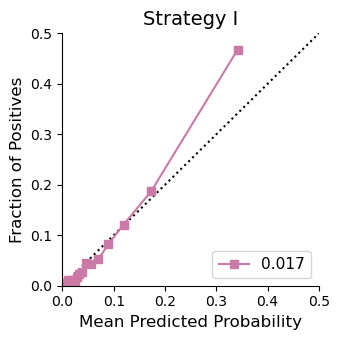

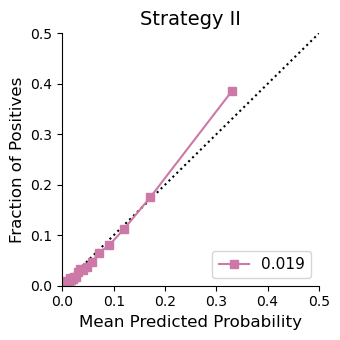

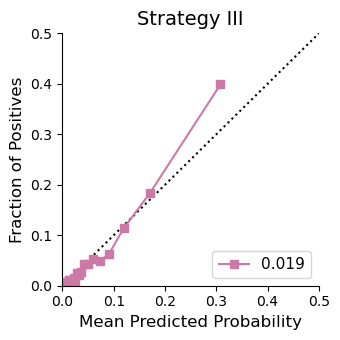

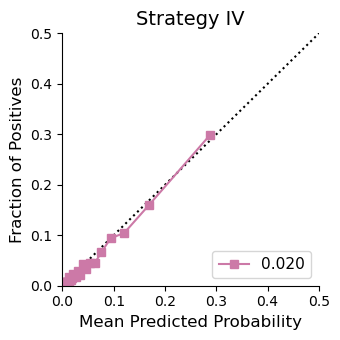

In [ ]:
plot_calibration(pred_df_I, title="Strategy I",   save_path=calibration_plot_model_I_n50,   n_bins=50)
plot_calibration(pred_df_II, title="Strategy II",  save_path=calibration_plot_model_II_n50,  n_bins=50)
plot_calibration(pred_df_III, title="Strategy III", save_path=calibration_plot_model_III_n50, n_bins=50)
plot_calibration(pred_df_IV, title="Strategy IV",  save_path=calibration_plot_model_IV_n50,  n_bins=50)

## Klingbeil et al. external test set

In [14]:
# load and de-duplicate the testing data (Klingbeil screen)

klingbeil_file_path = get_data_path(['data', 'output', 'models'], 'testing_data.csv')
test_df = pd.read_csv(klingbeil_file_path)

def resolve_sl_label(df):
    label_map = df.groupby(['genepair', 'DepMap_ID'])['SL_new'].any()
    df = df.drop_duplicates(subset=['genepair', 'DepMap_ID']).copy()
    df['SL_new_new'] = df.set_index(['genepair', 'DepMap_ID']).index.map(label_map)
    return df.reset_index(drop=True)

test_df_resolved = resolve_sl_label(test_df)

mismatch = test_df_resolved[test_df_resolved['SL_new'] != test_df_resolved['SL_new_new']]

print(f"Total rows: {len(test_df_resolved)}")
print(f"Matching labels: {len(test_df_resolved) - len(mismatch)}")
print(f"Mismatched labels: {len(mismatch)}")

mismatch[['genepair', 'cell_line', 'SL_new', 'SL_new_new']]

test_df = test_df_resolved.drop(columns=['SL_new']).rename(columns={'SL_new_new': 'SL_new'})
test_df.loc[test_df['genepair'] == 'AKT1_AKT2', ]

Total rows: 35467
Matching labels: 35380
Mismatched labels: 87


,GENE_COMBINATION,domain_combination,genepair,A1,A2,A1_entrez,A2_entrez,cell_line,DepMap_ID,GEMINI,...,either_in_complex,mean_complex_essentiality,colocalisation,interact,n_total_ppi,fet_ppi_overlap,gtex_spearman_corr,gtex_min_mean_expr,gtex_max_mean_expr,SL_new
1669,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,HEL,ACH-000004,0.288270,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,False
1670,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,T3M4,ACH-000085,2.041708,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,True
1671,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,HPAFII,ACH-000094,3.289536,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,True
1672,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,THP1,ACH-000146,1.781768,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,True
1673,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,NOMO1,ACH-000168,1.392973,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,True
1674,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,RD,ACH-000169,0.783456,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,True
1675,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,CORL311,ACH-000187,-0.626738,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,False
1676,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,SET2,ACH-000195,1.215378,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,True
1677,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,ASPC1,ACH-000222,3.431455,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,True
1678,AKT1:Kinase_domain;AKT2:Kinase_domain,Kinase_domain_Kinase_domain,AKT1_AKT2,AKT1,AKT2,207.0,208.0,H209,ACH-000290,0.274831,...,True,0.140482,0.25,True,429.0,47.402296,0.580697,37.389856,51.813468,False


In [15]:
file_RF_model_full = get_data_path(['data', 'output', 'models'], 'full_model.pickle')
with open(file_RF_model_full, 'rb') as file:
    full = pickle.load(file)

In [16]:
#probs = full.predict_proba(test_df[feature_columns_2])[:, 1]
X_klingbeil = test_df[feature_columns_2]
y_true = test_df['SL_new'].astype(int)

if isinstance(full, list):
    y_prob = np.mean([m.predict_proba(X_klingbeil)[:, 1] for m in full], axis=0)
else:
    y_prob = full.predict_proba(X_klingbeil)[:, 1]

# 4. Sanity check before plotting
print(f"n={len(y_true)}, prevalence={y_true.mean():.4f}, "
      f"Brier={brier_score_loss(y_true, y_prob):.4f}")

n=35467, prevalence=0.0416, Brier=0.0338


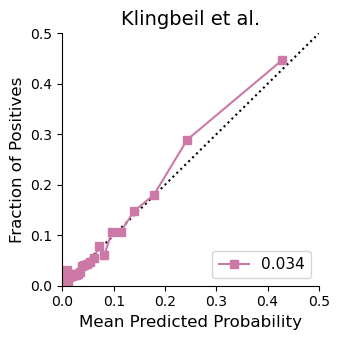

In [17]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
CalibrationDisplay.from_predictions(
    y_true, y_prob, n_bins=50, strategy="quantile",
    ax=ax, color="#CC79A7", name=f"{brier_score_loss(y_true, y_prob):.3f}",
)

handles, labels = ax.get_legend_handles_labels()
handles, labels = zip(*[(h, l) for h, l in zip(handles, labels) if l != "Perfectly calibrated"])

ax.set_xlim(0, 0.5); ax.set_ylim(0, 0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Mean Predicted Probability", fontsize=12)
ax.set_ylabel("Fraction of Positives", fontsize=12)
ax.set_title("Klingbeil et al.", fontsize=14)
ax.legend(handles, labels, title="", fontsize=11, frameon=True, loc="lower right")
plt.tight_layout()

#plt.savefig('/Users/narod/Library/CloudStorage/GoogleDrive-narod.kebabci@ucdconnect.ie/My Drive/GitRepos/context_specific_SL_prediction/figures/model_on_GEMINI/klingbeil_calibration.png', bbox_inches='tight', dpi=600)
plt.show()

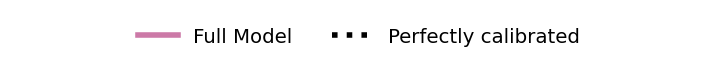

In [18]:
legend_labels = [
    "Full Model",
    "Perfectly calibrated",
    "Observed prevalence",
]

legend_styles = [
    {"color": "#CC79A7", "linestyle": "-"},
    {"color": "#000000",  "linestyle": ":"},
]

plt.figure(figsize=(9, 0.10))

for style in legend_styles:
    plt.plot([], [], color=style["color"], linestyle=style["linestyle"], linewidth=4)

plt.legend(
    legend_labels,
    fontsize=14.25,
    loc="upper center",
    ncol=len(legend_labels),
    frameon=False,
)

plt.gca().set_axis_off()
#plt.savefig('/Users/narod/Library/CloudStorage/GoogleDrive-narod.kebabci@ucdconnect.ie/My Drive/GitRepos/context_specific_SL_prediction/figures/model_on_GEMINI/legend.png', bbox_inches='tight', dpi=600)
plt.show()